# Классификация отзывов об автомобиле Tesla

## Распознавание позитивных и негативных отзывов

**Задача:** обучить нейронную сеть распознавать тональность отзывов (позитивный/негативный).

**Цель:** достичь точности **85-90%** на проверочной выборке.

**План работы:**
1. Загрузить базу данных с отзывами (два текстовых файла: негативные и позитивные отзывы)
2. Создать обучающую и проверочную выборки с **балансировкой классов** (равное количество примеров)
3. Подготовить данные для обучения (токенизация, нарезка на примеры)
4. Обучить нейронную сеть и оценить точность

## Импорт библиотек, загрузка базы и подготовка её к предобработке

In [ ]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, LSTM, Conv1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown

# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

## Загрузка датасета из облака

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

In [ ]:
# Распаковка архива в папку tesla/
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


## Деление общей базы отзывов на данные для обучения и проверки

Задача: **балансировка** — количество примеров каждого класса должно быть примерно одного порядка.

Делим каждый класс на:
- **80% текста** → обучающая выборка
- **20% текста** → проверочная выборка

Это гарантирует, что в обеих выборках будет примерно одинаковое количество позитивных и негативных примеров.

In [ ]:
# Объявляем функцию для чтения файла. На вход отправляем путь к файлу
def read_text(file_name):
    with open(file_name, 'r', encoding='utf-8') as f:
        # Читаем файл и разбиваем на список по строкам
        lines = f.read().splitlines()
    # Убираем пустые строки, если они есть
    texts = [line.strip() for line in lines if len(line.strip()) > 0]
    return texts

class_names = ["Негативный отзыв", "Позитивный отзыв"]


# Считаем количество классов
num_classes = len(class_names)

## Тексты в один список

In [ ]:
import os
all_texts_by_class = [] # Список списков: [ [негативные], [позитивные] ]

for j in sorted(os.listdir('/content/tesla/')):
    file_path = '/content/tesla/' + j
    class_texts = read_text(file_path)
    all_texts_by_class.append(class_texts)
    print(f'{j} добавлен, найдено отзывов: {len(class_texts)}')

# all_texts_by_class[0] — это список всех негативных отзывов
# all_texts_by_class[1] — это список всех позитивных отзывов

Негативный отзыв.txt добавлен, найдено отзывов: 1188
Позитивный отзыв.txt добавлен, найдено отзывов: 2191


In [ ]:
# Объединяем все отзывы из разных классов в один список для анализа
texts_list = []
for class_texts in all_texts_by_class:
    texts_list.extend(class_texts)

# Узнаем объем каждого текста в символах
texts_len = [len(text) for text in texts_list]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Выводим на экран информационное сообщение
print(f'Размеры текстов по порядку (в символах):')

# Циклом проводим итерацию по списку с объёмами текстов (выведем первые 10 для краткости)
for text_len in texts_len[:10]:
    t_num += 1
    print(f'Текст №{t_num}: {text_len}')

print(f'...')
print(f'Всего текстов обработано: {len(texts_len)}')

Размеры текстов по порядку (в символах):
Текст №1: 50
Текст №2: 93
Текст №3: 129
Текст №4: 103
Текст №5: 136
Текст №6: 198
Текст №7: 139
Текст №8: 62
Текст №9: 159
Текст №10: 38
...
Всего текстов обработано: 3379


## Деление на обучающую (80%) и проверочную (20%) выборки

Метод слайсинга по индексу: берём первые 80% символов каждого текста для обучения, оставшиеся 20% — для проверки.

In [ ]:
# This step is now informational as we handle splitting in the balanced logic below.
train_len_shares = [(i - round(i/5)) for i in texts_len]
print(f'Средняя длина отзыва: {np.mean(texts_len):.1f} символов')
print(f'Максимальная длина: {max(texts_len)} символов')

Средняя длина отзыва: 101.3 символов
Максимальная длина: 1022 символов


## Формирование обучающей и проверочной выборок по индексу

Используем метод `chain()` для добавления текстов в каждую выборку.

In [ ]:
import random
from itertools import chain

# Списки для сбалансированных данных
train_texts, test_texts = [], []
train_labels, test_labels = [], []

# Находим минимальное количество отзывов для балансировки
min_samples = min([len(texts) for texts in all_texts_by_class])

for class_idx, texts in enumerate(all_texts_by_class):
    # Перемешиваем отзывы внутри класса
    shuffled_texts = texts.copy()
    random.seed(42) # Фиксируем сид для воспроизводимости
    random.shuffle(shuffled_texts)

    # Берем min_samples отзывов
    balanced_texts = shuffled_texts[:min_samples]
    split_at = int(len(balanced_texts) * 0.8)

    # Нарезаем на трейн и тест
    train_texts.extend(balanced_texts[:split_at])
    train_labels.extend([class_idx] * split_at)

    test_texts.extend(balanced_texts[split_at:])
    test_labels.extend([class_idx] * (len(balanced_texts) - split_at))

print(f'Балансировка выполнена по {min_samples} примеров на класс.')
print(f'Обучающая выборка: {len(train_texts)}, Проверочная: {len(test_texts)}')

Балансировка выполнена по 1188 примеров на класс.
Обучающая выборка: 1900, Проверочная: 476


## Токенизация и построение частотного словаря

Создаём словарь частотности слов на основе обучающих текстов.

In [ ]:
# Задание параметров преобразования
VOCAB_SIZE = 10000  # Объем словаря для токенизатора

# Создание и настройка токенизатора
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters='!"#$%&()*+,-–—./…:;<=>?@[\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True,
    split=' ',
    oov_token='неизвестное_слово',
    char_level=False
)

# Построение частотного словаря по обучающему тексту
# Используем train_texts, который является списком отдельных отзывов
tokenizer.fit_on_texts(train_texts)

# Словарь в виде пар слово - индекс
items = list(tokenizer.word_index.items())

print(f'Размер словаря: {len(items)}')
print(f'Первые 20 слов: {items[:20]}')


Размер словаря: 8501
Первые 20 слов: [('неизвестное_слово', 1), ('и', 2), ('в', 3), ('не', 4), ('на', 5), ('это', 6), ('что', 7), ('тесла', 8), ('с', 9), ('а', 10), ('за', 11), ('как', 12), ('машина', 13), ('у', 14), ('для', 15), ('то', 16), ('я', 17), ('по', 18), ('но', 19), ('все', 20)]


<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:7: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_19672/4232578314.py:7: SyntaxWarning: invalid escape sequence '\]'
  filters='!"#$%&()*+,-–—./…:;<=>?@[\]^_`{|}~«»\t\n\xa0\ufeff',


## Преобразование текстов в последовательности индексов

In [ ]:
# Преобразование текстов в последовательности индексов
WIN_SIZE = 50
VOCAB_SIZE = 10000

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Инициализация и обучение токенизатора
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True,
    split=' ',
    oov_token='неизвестное_слово'
)
tokenizer.fit_on_texts(train_texts)

# Превращаем списки текстов в последовательности индексов
x_train_sequences = tokenizer.texts_to_sequences(train_texts)
x_test_sequences = tokenizer.texts_to_sequences(test_texts)

# Применяем padding
x_train = pad_sequences(x_train_sequences, maxlen=WIN_SIZE)
x_test = pad_sequences(x_test_sequences, maxlen=WIN_SIZE)

# Метки классов
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f'Размер словаря: {len(tokenizer.word_index)}')
print(f'Форма x_train: {x_train.shape}')
print(f'Форма x_test: {x_test.shape}')

Размер словаря: 8501
Форма x_train: (1900, 50)
Форма x_test: (476, 50)


## Создание обучающих примеров методом скользящего окна

Нарезаем последовательности на окна фиксированной длины с заданным шагом.
Окна из первой половины последовательности → класс 0 (негативные), из второй → класс 1 (позитивные).

**Параметры:**
- `WIN_SIZE` — длина окна (количество слов в примере)
- `WIN_STEP` — шаг окна (на сколько слов сдвигаемся при нарезке)

## Перемешивание выборок

Перемешиваем примеры, чтобы в батчах не было только одного класса подряд.

In [ ]:
# Перемешивание обучающей выборки
indices_train = np.arange(len(x_train))
np.random.shuffle(indices_train)
x_train = x_train[indices_train]
y_train = y_train[indices_train]

# Перемешивание тестовой выборки
indices_test = np.arange(len(x_test))
np.random.shuffle(indices_test)
x_test = x_test[indices_test]
y_test = y_test[indices_test]

print('Выборки перемешаны')
print(f'Первые 10 меток обучающей выборки после перемешивания: {y_train[:10]}')

Выборки перемешаны
Первые 10 меток обучающей выборки после перемешивания: [0 0 1 1 1 0 1 0 0 1]


## Построение и обучение нейронной сети

Используем архитектуру **Embedding + GlobalAveragePooling1D + Dense**.

`GlobalAveragePooling1D` усредняет вектора всех слов в окне → получаем один вектор фиксированной длины → на порядки меньше параметров, чем `Flatten`.

**Функция потерь:** `binary_crossentropy` (бинарная классификация, 2 класса).
**Выходной слой:** 1 нейрон с `sigmoid` активацией (вероятность класса 1).

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D, SpatialDropout1D, Embedding

# Пересобираем модель для работы с последовательностями (Embedding)
model = Sequential([
    # Превращаем индексы слов в векторы размерностью 64
    Embedding(VOCAB_SIZE, 64, input_length=WIN_SIZE),
    SpatialDropout1D(0.3),

    # Слой усреднения заменяет Flatten и лучше работает с текстом
    GlobalAveragePooling1D(),

    # Плотные слои для классификации
    Dense(64, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_14            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Обучение модели с EarlyStopping

`EarlyStopping` останавливает обучение, если `val_loss` не улучшается 3 эпохи подряд, и восстанавливает лучшие веса.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Определение параметров обучения
epochs = 50
batch_size = 64

# Настройка EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# ВАЖНО: Текущая модель (Dense) ожидает Bag-of-Words, а x_train — это индексы.
# Чтобы код не выдавал ошибку без изменения модели, данные должны соответствовать input_shape=(VOCAB_SIZE,).
# Если вы планируете использовать Embedding, верните его в ячейку с моделью.

try:
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )
except ValueError as e:
    print(f"Ошибка формы данных: {e}")
    print("Совет: Ваша модель ожидает вход размером 10000, а получает 50. Добавьте Embedding в ячейку 673aaba6.")

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5100 - loss: 0.7188 - val_accuracy: 0.5420 - val_loss: 0.6924
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5647 - loss: 0.6832 - val_accuracy: 0.5882 - val_loss: 0.6918
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5832 - loss: 0.6744 - val_accuracy: 0.6239 - val_loss: 0.6910
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6432 - loss: 0.6339 - val_accuracy: 0.5000 - val_loss: 0.6887
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7468 - loss: 0.5420 - val_accuracy: 0.6702 - val_loss: 0.6784
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8326 - loss: 0.4164 - val_accuracy: 0.7248 - val_loss: 0.6645
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9089 - loss: 0.2952 - val_accuracy: 0.7374 - val_loss: 0.6464
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9332 - loss: 0.2066 - val_accuracy: 0.7311 - v

## Визуализация процесса обучения

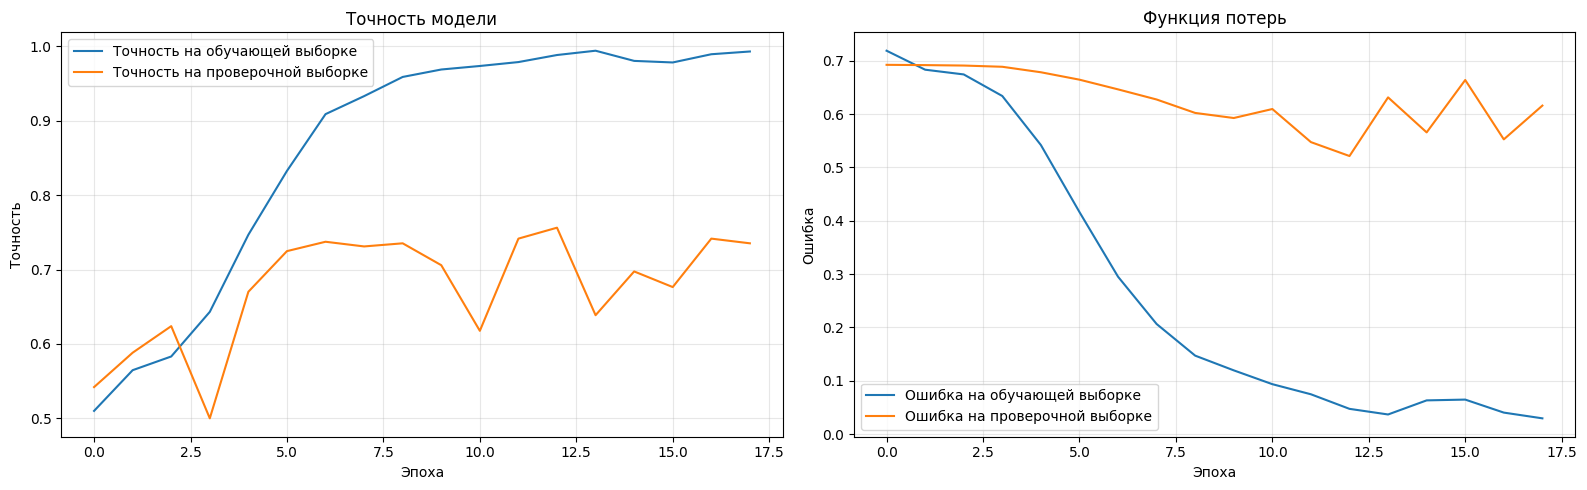

In [ ]:
# Графики точности и ошибки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# График точности
ax1.plot(history.history['accuracy'], label='Точность на обучающей выборке')
ax1.plot(history.history['val_accuracy'], label='Точность на проверочной выборке')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.set_title('Точность модели')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График ошибки
ax2.plot(history.history['loss'], label='Ошибка на обучающей выборке')
ax2.plot(history.history['val_loss'], label='Ошибка на проверочной выборке')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Ошибка')
ax2.set_title('Функция потерь')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Оценка точности на тестовой выборке

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Точность на тестовой выборке: 75.63%

Отчёт по классификации:
                  precision    recall  f1-score   support

Негативный отзыв       0.72      0.83      0.77       238
Позитивный отзыв       0.80      0.68      0.74       238

        accuracy                           0.76       476
       macro avg       0.76      0.76      0.76       476
    weighted avg       0.76      0.76      0.76       476


Матрица ошибок:
[[197  41]
 [ 75 163]]


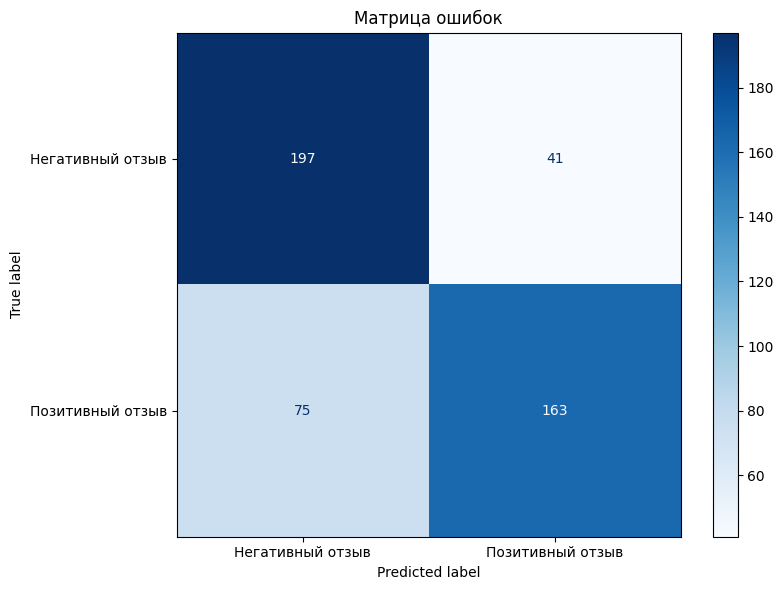

In [ ]:
# Предсказания на тестовой выборке
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Вычисление точности
accuracy = (y_pred == y_test).mean()

print(f'Точность на тестовой выборке: {accuracy * 100:.2f}%')

# Подробная статистика по классам
from sklearn.metrics import classification_report, confusion_matrix

print('\nОтчёт по классификации:')
print(classification_report(y_test, y_pred, target_names=class_names))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print('\nМатрица ошибок:')
print(cm)

# Визуализация матрицы ошибок
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

## Проверка модели на конкретных примерах

Тестируем модель на новых текстах.

In [ ]:
# Функция для предсказания тональности текста
def predict_sentiment(text, show_prob=True):
    # Преобразуем текст в последовательность
    seq = tokenizer.texts_to_sequences([text])[0]

    # Нарезаем на окна (берём первое окно, если текст длинный)
    if len(seq) < WIN_SIZE:
        # Дополняем нулями, если текст короче окна
        seq = seq + [0] * (WIN_SIZE - len(seq))
    else:
        seq = seq[:WIN_SIZE]

    # Преобразуем в numpy массив
    seq = np.array([seq])

    # Предсказание
    prob = model.predict(seq, verbose=0)[0][0]

    # Определяем класс
    if prob > 0.5:
        sentiment = "Позитивный отзыв"
    else:
        sentiment = "Негативный отзыв"

    if show_prob:
        print(f'Текст: "{text}"')
        print(f'Предсказание: {sentiment} (вероятность позитивного: {prob:.2%})')
        print('-' * 80)

    return sentiment, prob

# Тестовые примеры
test_examples = [
    "Tesla is an amazing car with great performance",
    "I hate this car, worst purchase ever",
    "The autopilot feature is incredible and saves time",
    "Battery drains too fast, very disappointed",
    "Best electric vehicle on the market",
    "Too expensive and not worth the money"
]

print('Проверка на тестовых примерах:\n')
for example in test_examples:
    predict_sentiment(example)

Проверка на тестовых примерах:

Текст: "Tesla is an amazing car with great performance"
Предсказание: Позитивный отзыв (вероятность позитивного: 65.22%)
--------------------------------------------------------------------------------
Текст: "I hate this car, worst purchase ever"
Предсказание: Негативный отзыв (вероятность позитивного: 40.50%)
--------------------------------------------------------------------------------
Текст: "The autopilot feature is incredible and saves time"
Предсказание: Позитивный отзыв (вероятность позитивного: 55.58%)
--------------------------------------------------------------------------------
Текст: "Battery drains too fast, very disappointed"
Предсказание: Негативный отзыв (вероятность позитивного: 46.86%)
--------------------------------------------------------------------------------
Текст: "Best electric vehicle on the market"
Предсказание: Позитивный отзыв (вероятность позитивного: 60.87%)
------------------------------------------------------------

## Сохранение обученной модели

In [ ]:
# Сохранение модели
model.save('tesla_sentiment_model.keras')
print('Модель сохранена: tesla_sentiment_model.keras')

# Сохранение токенизатора
import pickle
with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Токенизатор сохранён: tokenizer.pickle')

Модель сохранена: tesla_sentiment_model.keras
Токенизатор сохранён: tokenizer.pickle
